In the following notebook we are going to analyse and solve some hypotetical scenarios based on the data extracted from a water treatment plant

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re 
water_treatment_data = pd.read_csv(r"Datasets/datos/water+treatment+plant/water-treatment.csv") 
water_treatment_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 526 entries, 0 to 525
Data columns (total 39 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   D-1/3/90  526 non-null    str    
 1   44101     526 non-null    str    
 2   1.50      526 non-null    str    
 3   7.8       526 non-null    float64
 4   ?         526 non-null    str    
 5   407       526 non-null    str    
 6   166       526 non-null    str    
 7   66.3      526 non-null    str    
 8   4.5       526 non-null    str    
 9   2110      526 non-null    int64  
 10  7.9       526 non-null    float64
 11  ?.1       526 non-null    str    
 12  228       526 non-null    int64  
 13  70.2      526 non-null    str    
 14  5.5       526 non-null    str    
 15  2120      526 non-null    int64  
 16  7.9.1     526 non-null    float64
 17  ?.2       526 non-null    str    
 18  280       526 non-null    str    
 19  94        526 non-null    str    
 20  72.3      526 non-null    str    
 21  0.3 

We add the headers to the DataFrame 

In [9]:
variable_names = [
    'Date', 'Q-E', 'ZN-E', 'PH-E', 'DBO-E', 'DQO-E', 'SS-E', 'SSV-E', 'SED-E', 'COND-E', 
    'PH-P', 'DBO-P', 'SS-P', 'SSV-P', 'SED-P', 'COND-P', 'PH-D', 'DBO-D', 'DQO-D', 
    'SS-D', 'SSV-D', 'SED-D', 'COND-D', 'PH-S', 'DBO-S', 'DQO-S', 'SS-S', 'SSV-S', 
    'SED-S', 'COND-S', 'RD-DBO-P', 'RD-SS-P', 'RD-SED-P', 'RD-DBO-S', 'RD-DQO-S', 
    'RD-DBO-G', 'RD-DQO-G', 'RD-SS-G', 'RD-SED-G'
] #This list is was reflected in the documentation of the data 
water_treatment_data.columns = variable_names
water_treatment_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 526 entries, 0 to 525
Data columns (total 39 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      526 non-null    str    
 1   Q-E       526 non-null    str    
 2   ZN-E      526 non-null    str    
 3   PH-E      526 non-null    float64
 4   DBO-E     526 non-null    str    
 5   DQO-E     526 non-null    str    
 6   SS-E      526 non-null    str    
 7   SSV-E     526 non-null    str    
 8   SED-E     526 non-null    str    
 9   COND-E    526 non-null    int64  
 10  PH-P      526 non-null    float64
 11  DBO-P     526 non-null    str    
 12  SS-P      526 non-null    int64  
 13  SSV-P     526 non-null    str    
 14  SED-P     526 non-null    str    
 15  COND-P    526 non-null    int64  
 16  PH-D      526 non-null    float64
 17  DBO-D     526 non-null    str    
 18  DQO-D     526 non-null    str    
 19  SS-D      526 non-null    str    
 20  SSV-D     526 non-null    str    
 21  SED-

Now we set the date as our index and format it to datetime.

In [10]:
water_treatment_data.set_index('Date',inplace=True)
water_treatment_data.index = pd.to_datetime(water_treatment_data.index.str.replace('D-', ''),format='%d/%m/%y')
water_treatment_data

,Q-E,ZN-E,PH-E,DBO-E,DQO-E,SS-E,SSV-E,SED-E,COND-E,PH-P,...,COND-S,RD-DBO-P,RD-SS-P,RD-SED-P,RD-DBO-S,RD-DQO-S,RD-DBO-G,RD-DQO-G,RD-SS-G,RD-SED-G
Date,,,,,,,,,,,,,,,,,,,,,
1990-03-02,39024,3.00,7.7,?,443,214,69.2,6.5,2660,7.7,...,2590,?,60.7,94.8,?,80.8,?,79.5,92.1,100
1990-03-04,32229,5.00,7.6,?,528,186,69.9,3.4,1666,7.7,...,1888,?,58.2,95.6,?,52.9,?,75.8,88.7,98.5
1990-03-05,35023,3.50,7.9,205,588,192,65.6,4.5,2430,7.8,...,1840,33.1,64.2,95.3,87.3,72.3,90.2,82.3,89.6,100
1990-03-06,36924,1.50,8.0,242,496,176,64.8,4.0,2110,7.9,...,2120,?,62.7,95.6,?,71.0,92.1,78.2,87.5,99.5
1990-03-07,38572,3.00,7.8,202,372,186,68.8,4.5,1644,7.8,...,1764,?,59.7,96.5,86.7,78.3,90.1,73.1,84.9,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1991-08-26,32723,0.16,7.7,93,252,176,56.8,2.3,894,7.7,...,942,?,62.3,93.3,69.8,75.9,79.6,78.6,96.6,99.6
1991-08-27,33535,0.32,7.8,192,346,172,68.6,4.0,988,7.8,...,950,?,58.3,97.8,83.0,59.1,91.1,74.6,90.7,100
1991-08-28,32922,0.30,7.4,139,367,180,64.4,3.0,1060,7.5,...,1136,?,65.0,97.1,76.2,66.4,82.0,77.1,88.9,99


As we can see the null values are represented with '?' we replace the with NaN and calculate the percentage of nan values of each column

In [11]:
water_treatment_data.replace('?', np.nan, inplace=True)
water_treatment_data = water_treatment_data.apply(pd.to_numeric, errors='coerce') #We convert every value from String to numerical
null_percentages = water_treatment_data.isna().mean() * 100
null_report = null_percentages.to_frame(name='Per_NaN').sort_values(by='Per_NaN', ascending=False) #We calculate the amount of NaN values of each variable

print(null_report[null_report['Per_NaN'] > 0])

            Per_NaN
RD-DBO-P  11.596958
DBO-P      7.414449
RD-DBO-S   7.414449
RD-DBO-G   6.653992
RD-SED-G   5.893536
SED-S      5.323194
RD-SED-P   5.133080
DBO-D      5.133080
RD-DQO-S   4.942966
RD-DQO-G   4.752852
SED-D      4.752852
SED-E      4.752852
SED-P      4.562738
DBO-E      4.182510
DBO-S      4.182510
Q-E        3.422053
DQO-S      3.422053
SSV-S      3.231939
SSV-D      2.471483
SSV-P      2.091255
SSV-E      2.091255
DQO-D      1.711027
RD-SS-G    1.520913
DQO-E      1.140684
SS-S       0.950570
RD-SS-P    0.760456
ZN-E       0.570342
SS-D       0.380228
COND-S     0.190114
SS-E       0.190114
PH-S       0.190114


As we can see, none of them surpass the 20% failure threshold, so they all can be used. In the hypothetical case that between 20 to 40 percent were NaN, we would have to discern about the importance of the variable, and in the case that it was crucial we ought to make a solution, most likely a Digital Twin. Finally, in the case of more than 40 percent NaN, the data would not be representative.

But since NaN values aren't desirable, we are going to fill them with the forward fill technique.

In [12]:
water_treatment_data = water_treatment_data.ffill()
water_treatment_data

,Q-E,ZN-E,PH-E,DBO-E,DQO-E,SS-E,SSV-E,SED-E,COND-E,PH-P,...,COND-S,RD-DBO-P,RD-SS-P,RD-SED-P,RD-DBO-S,RD-DQO-S,RD-DBO-G,RD-DQO-G,RD-SS-G,RD-SED-G
Date,,,,,,,,,,,,,,,,,,,,,
1990-03-02,39024.0,3.00,7.7,NaN,443.0,214.0,69.2,6.5,2660,7.7,...,2590.0,NaN,60.7,94.8,NaN,80.8,NaN,79.5,92.1,100.0
1990-03-04,32229.0,5.00,7.6,NaN,528.0,186.0,69.9,3.4,1666,7.7,...,1888.0,NaN,58.2,95.6,NaN,52.9,NaN,75.8,88.7,98.5
1990-03-05,35023.0,3.50,7.9,205.0,588.0,192.0,65.6,4.5,2430,7.8,...,1840.0,33.1,64.2,95.3,87.3,72.3,90.2,82.3,89.6,100.0
1990-03-06,36924.0,1.50,8.0,242.0,496.0,176.0,64.8,4.0,2110,7.9,...,2120.0,33.1,62.7,95.6,87.3,71.0,92.1,78.2,87.5,99.5
1990-03-07,38572.0,3.00,7.8,202.0,372.0,186.0,68.8,4.5,1644,7.8,...,1764.0,33.1,59.7,96.5,86.7,78.3,90.1,73.1,84.9,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1991-08-26,32723.0,0.16,7.7,93.0,252.0,176.0,56.8,2.3,894,7.7,...,942.0,40.8,62.3,93.3,69.8,75.9,79.6,78.6,96.6,99.6
1991-08-27,33535.0,0.32,7.8,192.0,346.0,172.0,68.6,4.0,988,7.8,...,950.0,40.8,58.3,97.8,83.0,59.1,91.1,74.6,90.7,100.0
1991-08-28,32922.0,0.30,7.4,139.0,367.0,180.0,64.4,3.0,1060,7.5,...,1136.0,40.8,65.0,97.1,76.2,66.4,82.0,77.1,88.9,99.0


As we can see there are some NaN values in the first registers that can't be solved with the fordward fill technique, to solve this we use the backward fill so we assure there are not any NaN

In [13]:
water_treatment_data = water_treatment_data.bfill()
total_nans = water_treatment_data.isna().sum().sum() #We make sure that we have not skipped any NaN
print(f"NaN values in the data frame: {total_nans}")

NaN values in the data frame: 0


Now that we have cleaned the NaN values, we can search for individual outliers. For this, we will use the Interquartile Range (IQR) Method, which is based on establishing a threshold and discriminating the values that are further away than an adjusted distance—in this case, 1.5 times the IQR.

In [14]:
#We implement the IQR and find the outliers
def detect_outliers_iqr(df, column): 
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_limit) | (df[column] > upper_limit)]
    return outliers, lower_limit, upper_limit
#We create a dataset to store the info about each variable
outliers_summary = []
numeric_columns = water_treatment_data.select_dtypes(include=['number']).columns
for col in numeric_columns:
    outliers, lower, upper = detect_outliers_iqr(water_treatment_data, col)
    outliers_summary.append({
        'Variable': col,
        'N_Outliers': len(outliers),
        'Pct_Outliers': round(len(outliers) / len(water_treatment_data) * 100, 2),
        'Lower_Limit': round(lower, 2),
        'Upper_Limit': round(upper, 2)
    })

summary = pd.DataFrame(outliers_summary).sort_values('Pct_Outliers', ascending=False)
print(summary)

    Variable  N_Outliers  Pct_Outliers  Lower_Limit  Upper_Limit
20     SED-D          44          8.37        -0.25         0.95
5       SS-E          39          7.41        62.00       350.00
11      SS-P          39          7.41        52.00       404.00
31  RD-SED-P          36          6.84        77.50       107.10
36   RD-SS-G          36          6.84        79.50       101.10
25      SS-S          35          6.65        -1.00        39.00
37  RD-SED-G          34          6.46        98.25       101.05
1       ZN-E          33          6.27        -2.25         6.15
27     SED-S          33          6.27        -0.03         0.05
33  RD-DQO-S          30          5.70        44.03        94.02
19     SSV-D          26          4.94        50.73        96.72
34  RD-DBO-G          26          4.94        80.21        99.71
6      SSV-E          24          4.56        34.85        90.45
32  RD-DBO-S          23          4.37        70.90        98.10
12     SSV-P          20 

Now we are looking for anomal global messurements, for this we use Isolation Forest to look for the 5% most different messurements. 

In [15]:
from sklearn.ensemble import IsolationForest

modelo_outliers = IsolationForest(contamination=0.05, random_state=7)
water_treatment_data['Outlier_Global'] = modelo_outliers.fit_predict(water_treatment_data)
anomalias = water_treatment_data[water_treatment_data['Outlier_Global'] == -1]

For the validation of our model we represent the eficiency of the plant compared to the amount of solids painting in red the anomal registers.

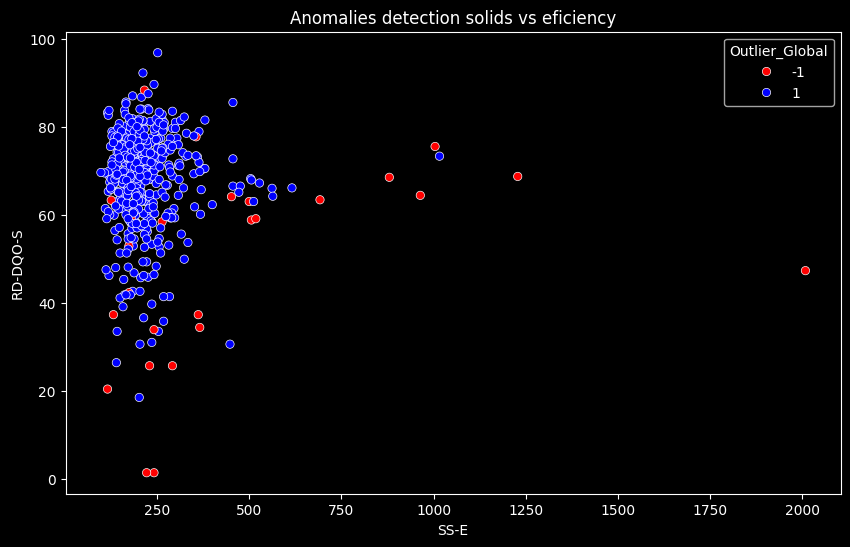

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(data=water_treatment_data, x='SS-E', y='RD-DQO-S', hue='Outlier_Global', palette={1: 'blue', -1: 'red'})
plt.title('Anomalies detection solids vs eficiency')
plt.show()